# Modelo Random Forest - Seguro Auto

Objetivo: identificar clientes com maior probabilidade de `sinistro_grave_perda_total_12m = 1`.

A base analisada possui 100.000 linhas, 62 colunas e target desbalanceado, com aproximadamente 6,47% de casos positivos.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)
from sklearn.inspection import permutation_importance

import joblib

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

## 1. Carregar o arquivo CSV

Execute a celula abaixo e selecione o arquivo `seguro_auto_historico.csv`.

In [ ]:
uploaded = files.upload()

csv_name = 'seguro_auto_historico.csv'
df = pd.read_csv(csv_name)

print(df.shape)
df.head()

Saving seguro_auto_historico.csv to seguro_auto_historico (1).csv
(100000, 62)


,id_cliente,ano_contratacao,mes_contratacao,canal_venda,idade,sexo,estado_civil,qtde_filhos,estado,regiao,cidade_porte,profissao_grupo,renda_mensal_estimada,score_credito,tempo_habilitacao_anos,pontos_cnh,multas_24m,multas_graves_24m,sinistros_anteriores,sinistros_12m_anteriores,acionamentos_guincho_24m,cancelamento_apolice_anterior,marca,modelo,ano_fabricacao,ano_modelo,idade_veiculo,categoria_veiculo,tipo_combustivel,cambio,potencia_cv,valor_veiculo,km_total,uso_principal,usa_carro_para_trabalho,frequencia_uso_semana,km_por_ano_estimado,periodo_uso_predominante,circula_em_rodovia,regiao_circulacao_risco,possui_garagem_residencial,tipo_garagem_residencial,possui_garagem_trabalho,tipo_estacionamento_trabalho,dorme_na_rua_frequencia,revisoes_em_dia,qtde_revisoes_24m,atraso_medio_revisao_dias,troca_pneus_24m,troca_freios_24m,historico_manutencao_score,alertas_manutencao_ativos,valor_segurado,premio_seguro,franquia,tipo_cobertura,assistencia_24h,carro_reserva,protecao_vidros,classe_bonus,desconto_comercial,sinistro_grave_perda_total_12m
0,100000,2024,12,banco_parceiro,50,F,casado,1,SP,Sudeste,grande,saude,3424.50,898.0,30.3,0,0,0,1,0,1,0,Honda,Fit,2022,2022,2,hatch,flex,automatico,119.0,68873.08,12222,pessoal,0,3,5746.0,variado,0,medio,1,descoberta,1,nao_se_aplica,nunca,1,4,1.5,1,1,94.9,1,67885.85,1704.48,2715.43,intermediaria,0,1,1,10,20.17,0
1,100001,2023,12,telefone,72,F,casado,2,AL,Nordeste,media,administrativo,3476.89,914.0,51.2,13,2,1,0,0,2,0,Chevrolet,Cruze,2019,2019,4,sedan,eletrico,automatico,NaN,77554.00,206750,entregas,1,7,49321.0,variado,0,medio,0,nenhuma,0,estacionamento_coberto,raramente,0,2,17.3,1,1,87.3,0,72394.33,2594.61,4343.66,intermediaria,1,1,1,10,14.67,0
2,100002,2025,12,app,24,M,solteiro,0,SC,Sul,media,educacao,3239.09,784.0,6.0,6,1,1,2,0,1,0,Toyota,Yaris,2014,2015,10,hatch,flex,manual,109.0,29413.62,63692,pessoal,0,2,NaN,variado,0,alto,0,nenhuma,0,nao_se_aplica,sempre,0,4,26.9,0,0,NaN,2,28890.12,1595.85,1444.51,intermediaria,1,1,0,0,5.88,0
3,100003,2024,12,app,38,F,solteiro,3,BA,Nordeste,grande,saude,20842.94,960.0,13.6,10,2,0,1,1,0,0,BMW,X1,2022,2022,2,luxo,gasolina,automatico,188.0,289435.35,22162,pessoal,0,4,9405.0,manha,1,muito_alto,1,condominio,1,nao_se_aplica,nunca,1,4,2.3,0,0,88.5,0,280723.40,7188.11,11228.94,intermediaria,1,1,1,4,9.61,0
4,100004,2020,11,telefone,61,M,divorciado,2,PR,Sul,grande,comercial,NaN,980.0,41.8,5,1,0,0,0,1,0,Hyundai,Tucson,2016,2016,4,suv,gasolina,automatico,135.0,65247.54,195616,entregas,1,6,43647.0,variado,0,medio,0,nenhuma,0,estacionamento_aberto,raramente,1,3,5.4,1,0,85.5,0,63105.55,1278.45,3155.28,completa,1,0,0,10,7.38,0


## 2. Opcional: salvar em Parquet

Parquet melhora leitura/escrita e preserva tipos, mas nao melhora o modelo diretamente.

In [ ]:
df.to_parquet('seguro_auto_historico.parquet', index=False)
# Para carregar novamente em outra execucao:
# df = pd.read_parquet('seguro_auto_historico.parquet')

## 3. Checagens iniciais

In [ ]:
target = 'sinistro_grave_perda_total_12m'

display(df.info())
display(df[target].value_counts())
display(df[target].value_counts(normalize=True).mul(100).round(2))

taxa_sinistro = df[target].mean()
print(f'Taxa de perda total: {taxa_sinistro:.2%}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 62 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id_cliente                      100000 non-null  int64  
 1   ano_contratacao                 100000 non-null  int64  
 2   mes_contratacao                 100000 non-null  int64  
 3   canal_venda                     100000 non-null  object 
 4   idade                           100000 non-null  int64  
 5   sexo                            100000 non-null  object 
 6   estado_civil                    100000 non-null  object 
 7   qtde_filhos                     100000 non-null  int64  
 8   estado                          100000 non-null  object 
 9   regiao                          100000 non-null  object 
 10  cidade_porte                    100000 non-null  object 
 11  profissao_grupo                 100000 non-null  object 
 12  renda_mensal_esti

None

,count
sinistro_grave_perda_total_12m,
0,93532
1,6468


,proportion
sinistro_grave_perda_total_12m,
0,93.53
1,6.47


Taxa de perda total: 6.47%


## 4. Valores ausentes

In [ ]:
missing = df.isna().sum().sort_values(ascending=False).to_frame('qtde_nulos')
missing['perc_nulos'] = (missing['qtde_nulos'] / len(df) * 100).round(2)
missing.head(20)

,qtde_nulos,perc_nulos
km_por_ano_estimado,9601,9.60
historico_manutencao_score,7991,7.99
renda_mensal_estimada,7925,7.92
potencia_cv,7043,7.04
score_credito,6009,6.01
valor_veiculo,5654,5.65
desconto_comercial,4040,4.04
valor_segurado,10,0.01
sexo,0,0.00
idade,0,0.00


## 5. Distribuicao do target

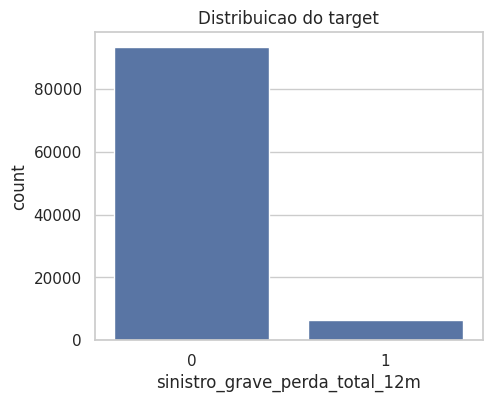

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x=target)
plt.title('Distribuicao do target')
plt.show()

## 6. Correlacao das variaveis numericas

A matriz de correlacao ajuda na exploracao, mas nao deve ser o unico criterio de selecao de variaveis.

,sinistro_grave_perda_total_12m
pontos_cnh,0.161599
multas_24m,0.159618
multas_graves_24m,0.133023
sinistros_anteriores,0.130836
classe_bonus,-0.130555
score_credito,-0.127623
atraso_medio_revisao_dias,0.117634
idade,-0.116189
tempo_habilitacao_anos,-0.114967
sinistros_12m_anteriores,0.108833


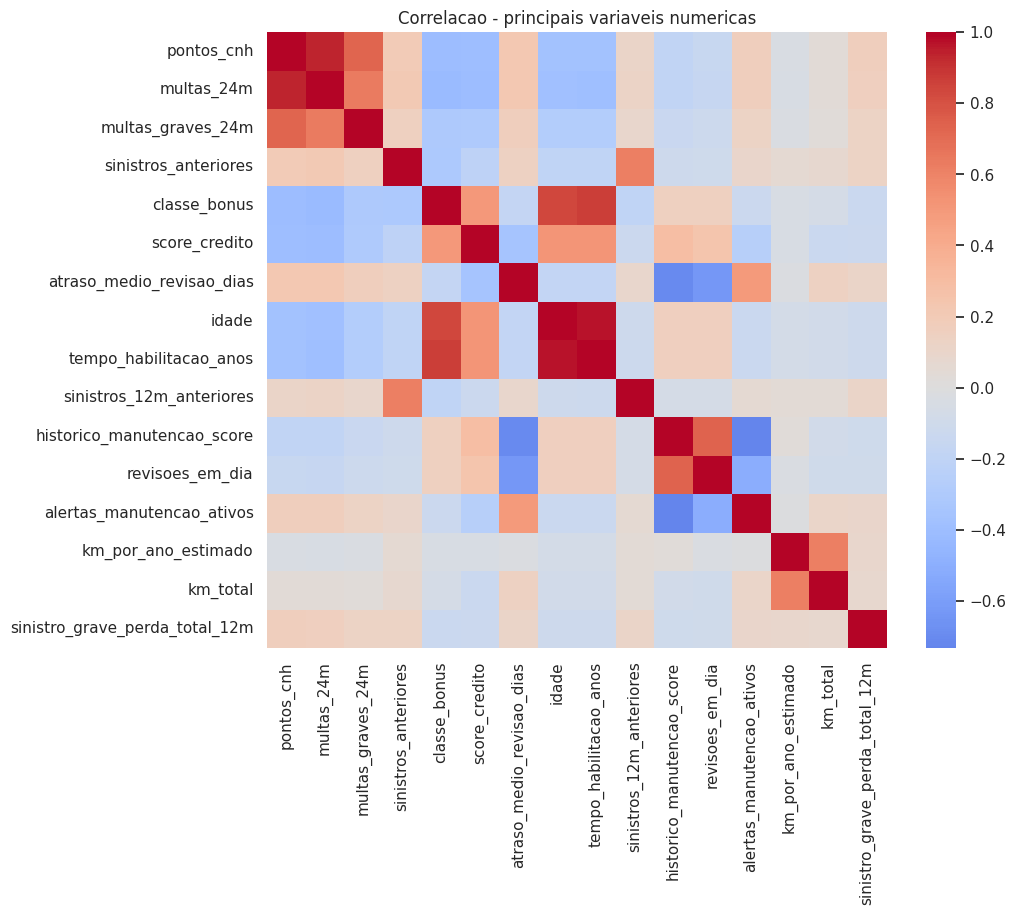

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64']).copy()

corr_target = (
    num_df.corr(numeric_only=True)[target]
          .drop(target)
          .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(corr_target.head(20))

plt.figure(figsize=(10, 8))
top_num_cols = corr_target.head(15).index.tolist() + [target]
sns.heatmap(df[top_num_cols].corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlacao - principais variaveis numericas')
plt.show()

## 7. Analise de variaveis categoricas

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols

['canal_venda',
 'sexo',
 'estado_civil',
 'estado',
 'regiao',
 'cidade_porte',
 'profissao_grupo',
 'marca',
 'modelo',
 'categoria_veiculo',
 'tipo_combustivel',
 'cambio',
 'uso_principal',
 'periodo_uso_predominante',
 'regiao_circulacao_risco',
 'tipo_garagem_residencial',
 'tipo_estacionamento_trabalho',
 'dorme_na_rua_frequencia',
 'tipo_cobertura']

In [ ]:
def taxa_por_categoria(data, coluna, target):
    return (
        data.groupby(coluna)[target]
            .agg(['count', 'mean'])
            .rename(columns={'count': 'qtde', 'mean': 'taxa_sinistro'})
            .sort_values('taxa_sinistro', ascending=False)
    )

display(taxa_por_categoria(df, 'regiao_circulacao_risco', target))
display(taxa_por_categoria(df, 'tipo_cobertura', target))
display(taxa_por_categoria(df, 'uso_principal', target))

,qtde,taxa_sinistro
regiao_circulacao_risco,,
muito_alto,21225,0.086266
alto,26329,0.068214
baixo,19300,0.055337
medio,33146,0.053491


,qtde,taxa_sinistro
tipo_cobertura,,
basica,23000,0.067609
intermediaria,34358,0.067233
completa,31201,0.063460
premium,11441,0.054453


,qtde,taxa_sinistro
uso_principal,,
aplicativo,8952,0.129468
entregas,8364,0.098996
trabalho,18175,0.059257
misto,15412,0.057033
pessoal,43060,0.051579
viagens,6037,0.050356


## 8. Separar treino e teste

`id_cliente` sera removido porque e identificador e nao deve ser usado como preditor.

In [ ]:
cols_remover = ['id_cliente']

X = df.drop(columns=[target] + cols_remover)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)
print('Taxa target treino:', y_train.mean())
print('Taxa target teste:', y_test.mean())

(80000, 60) (20000, 60)
Taxa target treino: 0.064675
Taxa target teste: 0.0647


## 9. Pipeline de preprocessamento e Random Forest

In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=50))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', rf)
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['ano_contratacao',
                                                   'mes_contratacao', 'idade',
                                                   'qtde_filhos',
                                                   'renda_mensal_estimada',
                                                   'score_credito',
                                                   'tempo_habilitacao_anos',
                                                   'pontos_cnh', 'multas_24m',
                                                   'multas_graves_24m',
                                                   'sinistros_anteriores',
                                                   'sinistros_12m_anteriores',
                                                   'aci...
                                                   'modelo',
                                                   'categoria_veiculo',
                                                   'tipo_combustivel', 'cambio',
                                                   'uso_principal',
                                                   'periodo_uso_predominante',
                                                   'regiao_circulacao_risco',
                                                   'tipo_garagem_residencial',
                                                   'tipo_estacionamento_trabalho',
                                                   'dorme_na_rua_frequencia',
                                                   'tipo_cobertura'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=20, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

## 10. Avaliar modelo com threshold 0.50

              precision    recall  f1-score   support

           0       0.95      0.90      0.92     18706
           1       0.20      0.36      0.25      1294

    accuracy                           0.86     20000
   macro avg       0.57      0.63      0.59     20000
weighted avg       0.90      0.86      0.88     20000

ROC AUC: 0.743977996133451
PR AUC: 0.18478830751150827


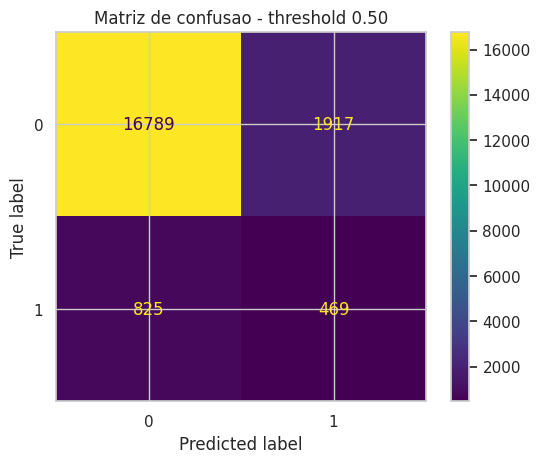

In [ ]:
y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred_050 = (y_proba >= 0.50).astype(int)

print(classification_report(y_test, y_pred_050))
print('ROC AUC:', roc_auc_score(y_test, y_proba))
print('PR AUC:', average_precision_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred_050)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format='d')
plt.title('Matriz de confusao - threshold 0.50')
plt.show()

## 11. Escolher threshold de risco

Como a classe 1 e minoritaria, o threshold 0.50 pode deixar passar clientes ruins. Teste cortes diferentes.

In [ ]:
thresholds = np.arange(0.05, 0.80, 0.05)
linhas = []

for th in thresholds:
    pred = (y_proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    linhas.append({
        'threshold': round(th, 2),
        'precision_classe_1': precision,
        'recall_classe_1': recall,
        'f1_classe_1': f1,
        'clientes_revisao_ou_bloqueio': int(tp + fp),
        'sinistros_capturados': int(tp),
        'sinistros_nao_capturados': int(fn)
    })

threshold_df = pd.DataFrame(linhas)
threshold_df

,threshold,precision_classe_1,recall_classe_1,f1_classe_1,clientes_revisao_ou_bloqueio,sinistros_capturados,sinistros_nao_capturados
0,0.05,0.064706,1.000000,0.121548,19998,1294,0
1,0.10,0.066611,0.989954,0.124823,19231,1281,13
2,0.15,0.077138,0.938176,0.142555,15738,1214,80
3,0.20,0.092319,0.869397,0.166914,12186,1125,169
4,0.25,0.107143,0.813756,0.189354,9828,1053,241
5,0.30,0.120659,0.741113,0.207531,7948,959,335
6,0.35,0.138137,0.662287,0.228594,6204,857,437
7,0.40,0.153138,0.565688,0.241027,4780,732,562
8,0.45,0.174050,0.470634,0.254121,3499,609,685
9,0.50,0.196563,0.362442,0.254891,2386,469,825


              precision    recall  f1-score   support

           0       0.97      0.63      0.76     18706
           1       0.12      0.74      0.21      1294

    accuracy                           0.63     20000
   macro avg       0.55      0.68      0.48     20000
weighted avg       0.92      0.63      0.73     20000



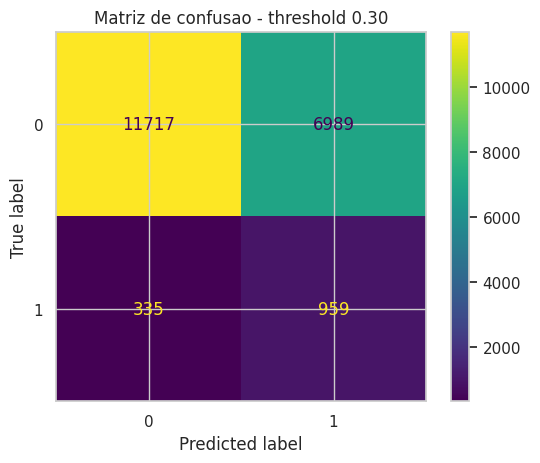

In [ ]:
threshold_escolhido = 0.30
y_pred_custom = (y_proba >= threshold_escolhido).astype(int)

print(classification_report(y_test, y_pred_custom))

cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format='d')
plt.title(f'Matriz de confusao - threshold {threshold_escolhido:.2f}')
plt.show()

## 12. Curvas ROC e Precision-Recall

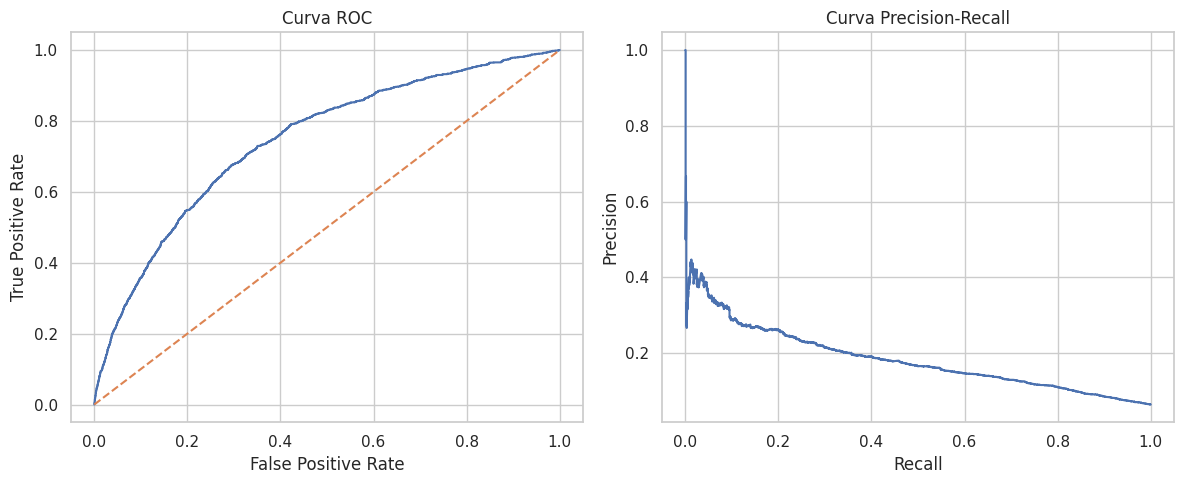

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')

plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')

plt.tight_layout()
plt.show()

## 13. Importancia das variaveis

,feature,importance
28,num__atraso_medio_revisao_dias,0.044851
22,num__km_por_ano_estimado,0.043330
5,num__score_credito,0.040963
8,num__multas_24m,0.040050
7,num__pontos_cnh,0.038272
10,num__sinistros_anteriores,0.038012
6,num__tempo_habilitacao_anos,0.037329
2,num__idade,0.036073
31,num__historico_manutencao_score,0.033841
19,num__km_total,0.032178


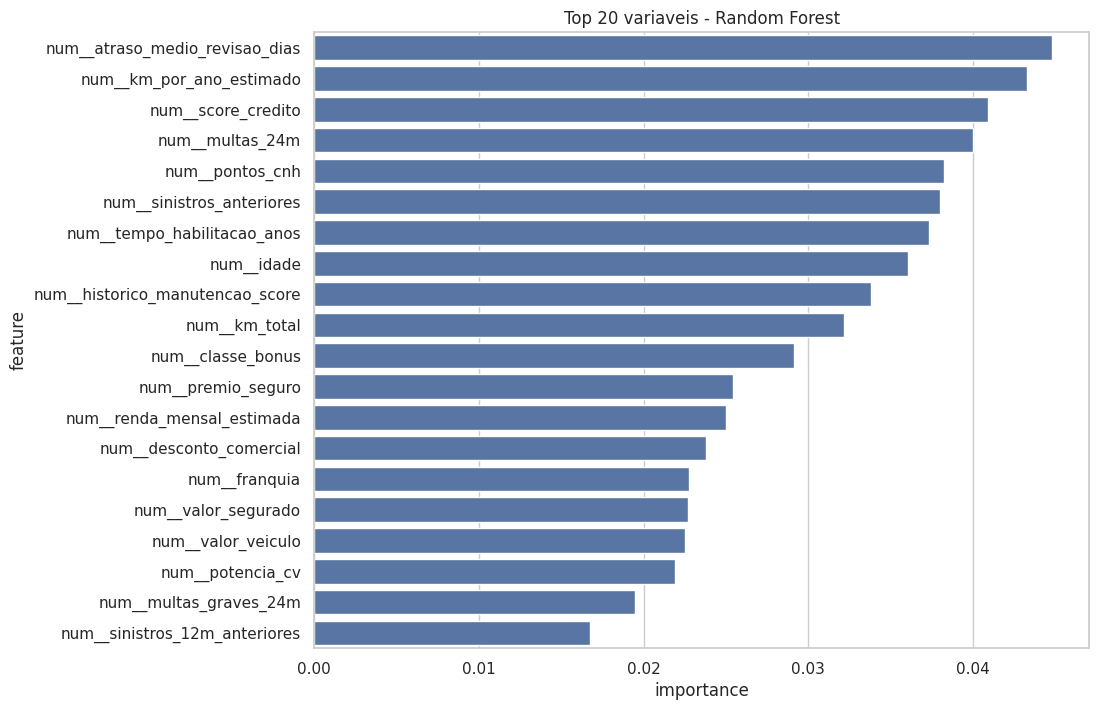

In [ ]:
feature_names = pipe.named_steps['prep'].get_feature_names_out()
importances = pipe.named_steps['model'].feature_importances_

fi = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
      .sort_values('importance', ascending=False)
)

display(fi.head(30))

plt.figure(figsize=(10, 8))
sns.barplot(data=fi.head(20), x='importance', y='feature')
plt.title('Top 20 variaveis - Random Forest')
plt.show()

In [ ]:
sample_size = min(10000, len(X_test))
X_test_sample = X_test.sample(sample_size, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

perm = permutation_importance(
    pipe,
    X_test_sample,
    y_test_sample,
    scoring='average_precision',
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std
    })
    .sort_values('importance_mean', ascending=False)
)

perm_df.head(20)

,feature,importance_mean,importance_std
15,multas_24m,0.008061,0.001663
17,sinistros_anteriores,0.005983,0.001564
3,idade,0.005460,0.002778
32,uso_principal,0.004642,0.001704
35,km_por_ano_estimado,0.004376,0.002289
14,pontos_cnh,0.003862,0.002330
38,regiao_circulacao_risco,0.003852,0.001300
12,score_credito,0.003513,0.002127
13,tempo_habilitacao_anos,0.003231,0.003119
18,sinistros_12m_anteriores,0.002592,0.000600


## 14. Gerar score de risco para todos os clientes

In [ ]:
df_resultado = df.copy()
df_resultado['probabilidade_perda_total'] = pipe.predict_proba(X)[:, 1]
df_resultado['classificacao_risco'] = np.where(
    df_resultado['probabilidade_perda_total'] >= threshold_escolhido,
    'alto_risco',
    'baixo_risco'
)

df_resultado[[
    'id_cliente',
    'probabilidade_perda_total',
    'classificacao_risco',
    'premio_seguro',
    'valor_segurado',
    target
]].head()

,id_cliente,probabilidade_perda_total,classificacao_risco,premio_seguro,valor_segurado,sinistro_grave_perda_total_12m
0,100000,0.171635,baixo_risco,1704.48,67885.85,0
1,100001,0.376293,alto_risco,2594.61,72394.33,0
2,100002,0.491203,alto_risco,1595.85,28890.12,0
3,100003,0.326014,alto_risco,7188.11,280723.40,0
4,100004,0.250575,baixo_risco,1278.45,63105.55,0


## 15. Estimativa simples de prejuizo esperado

Esta formula e uma aproximacao para discussao de negocio. Ajuste conforme a regra real da seguradora.

In [ ]:
df_resultado['prejuizo_esperado_aproximado'] = (
    df_resultado['probabilidade_perda_total'] * df_resultado['valor_segurado']
    - df_resultado['premio_seguro']
)

df_resultado[[
    'id_cliente',
    'probabilidade_perda_total',
    'prejuizo_esperado_aproximado',
    'premio_seguro',
    'valor_segurado',
    'classificacao_risco'
]].sort_values('prejuizo_esperado_aproximado', ascending=False).head(20)

,id_cliente,probabilidade_perda_total,prejuizo_esperado_aproximado,premio_seguro,valor_segurado,classificacao_risco
89990,189990,0.416977,362352.152912,14589.24,903985.660,alto_risco
74553,174553,0.827433,334102.969649,17318.20,424712.300,alto_risco
20967,120967,0.711648,321722.360088,16265.00,474936.430,alto_risco
37593,137593,0.722687,319790.749798,22494.37,473628.210,alto_risco
58939,158939,0.732759,316700.027899,14523.32,452022.160,alto_risco
48878,148878,0.747196,313157.056907,22491.44,449210.810,alto_risco
39936,139936,0.703605,310331.345781,15792.97,463504.940,alto_risco
26199,126199,0.670708,307067.742233,15287.50,480619.200,alto_risco
23258,123258,0.648322,302985.914583,7105.00,478297.975,alto_risco
17855,117855,0.706521,292451.231171,13011.22,432347.490,alto_risco


## 16. Exportar resultado e modelo

In [ ]:
df_resultado.to_csv('clientes_score_risco_seguro.csv', index=False)
joblib.dump(pipe, 'modelo_random_forest_seguro.pkl')

files.download('clientes_score_risco_seguro.csv')
files.download('modelo_random_forest_seguro.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 17. Opcional: busca de hiperparametros

Execute somente se tiver tempo, pois pode demorar.

In [ ]:
param_dist = {
    'model__n_estimators': [300, 500, 800],
    'model__max_depth': [None, 8, 12, 16, 24],
    'model__min_samples_leaf': [10, 20, 50, 100],
    'model__max_features': ['sqrt', 'log2', 0.5]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=15,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

best_pipe = search.best_estimator_
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print('ROC AUC:', roc_auc_score(y_test, y_proba_best))
print('PR AUC:', average_precision_score(y_test, y_proba_best))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
